# 1. Notebook kernel setup

After cloning repository at https://github.com/EstebanRivera08/PySonoGen, and the uv package, go on terminal to the location of the repository and run the following command to install the required packages:

`` uv run pycalib ``

To run these jupyter notebooks, the .venv environment of the project must be used as kernel.
To do so, from the repository path, you can run.

`` uv run -m ipykernel install --user --name=.venv --display-name "PySonoGen (.venv)" ``

This will create a jupyter kernel named 'PySonoGen (.venv)', that one can then select as kernel
of the notebook.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pyvista as pv
%load_ext autoreload
%autoreload 2


# 2. Define Matrix Transducer

In [2]:
import pysonogen.transducers as Transducers
print(Transducers.available_transducers())

['LinearArrayTransducer', 'MatrixArrayTransducer', 'Domino', 'Zeus_Matrix']


In [3]:
# Create transducer with elevation focus
tx_N_elem_x = 55
tx_N_elem_y = 55
tx_elem_width_mm = 0.29
tx_elem_height_mm = 0.29

tx_pitch_mm = 0.3

tx_kerf_x_mm = tx_pitch_mm - tx_elem_width_mm
tx_kerf_y_mm = tx_pitch_mm - tx_elem_height_mm

tx_freq = 10 # MHz

directivity = 30 

c = 1540.0  # speed of sound in soft tissue (m/s)

Zeus_Matrix = Transducers.MatrixArrayTransducer(
        N_elem_x        = tx_N_elem_x,
        N_elem_y        = tx_N_elem_y,
        elem_width_mm   = tx_elem_width_mm,
        elem_height_mm  = tx_elem_height_mm,
        kerf_x_mm       = tx_kerf_x_mm,
        kerf_y_mm       = tx_kerf_y_mm,
        no_sub_x        = 2,
        no_sub_y        = 2,
        frequency_Hz    = tx_freq*1e6, 
        dir_angle_deg   = directivity
)

print(Zeus_Matrix)

MatrixArrayTransducer initialized with 3025 elements and 12100 patches.
Transducer initialized in 0.0650 seconds.
MatrixArrayTransducer(n_elem_x=55, n_elem_y=55, el_w_mm=0.29, kerf_x_mm=0.010000000000000009, kerf_y_mm=0.010000000000000009, no_sub_x=2, no_sub_y=2, fc_Hz=10000000.0)


In [4]:
# Focalization spot
focus_mm =  np.array([0, 0, 8])  # mm [x, y, z]

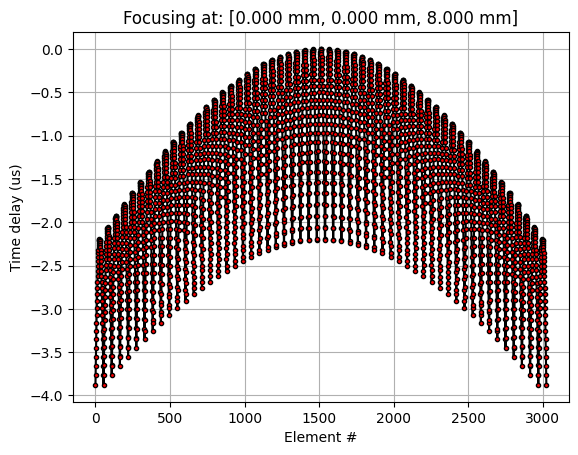

In [5]:
delays = Zeus_Matrix.compute_delays(focus_mm = focus_mm, plot = True)

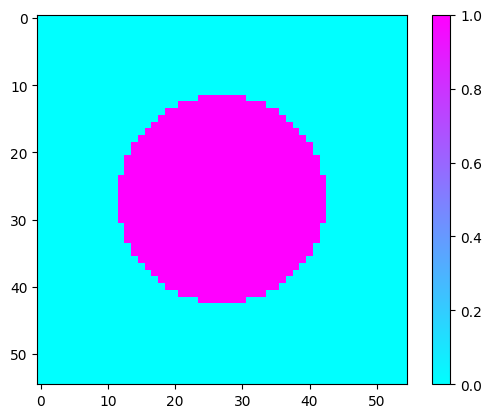

In [6]:
F_over_D = 1
apodization = Zeus_Matrix.compute_apodization(focus_mm = focus_mm, F_over_D = F_over_D, apodization_type='circular', plot = True)

In [7]:
Zeus_Matrix.show()  # Add this parameter

Widget(value='<iframe src="http://localhost:58253/index.html?ui=P_0x22a2e9430b0_0&reconnect=auto" class="pyvis…

# 3. Define field grid

In [8]:
import pysonogen
from pysonogen import pyfield


In [9]:
field_info_mm = {
    "x_extent" : [-0.25+focus_mm[0], 0.25+focus_mm[0]],
    "y_extent" : [-0.25+focus_mm[1], 0.25+focus_mm[1]],
    "z_extent" : [-1+focus_mm[2], 1+focus_mm[2]],
    "dx" : 0.025,
    "dy" : 0.025,
    "dz" : 0.05,
}

In [10]:
x, y, z, field_points = pyfield.create_simulation_grid(field_info_mm)

In [11]:
Zeus_Matrix_mesh = Zeus_Matrix.get_mesh()

In [12]:
Matrix_field = pyfield.PyField(Zeus_Matrix)

Successfully initialized PyField with 
 MatrixArrayTransducer(n_elem_x=55, n_elem_y=55, el_w_mm=0.29, kerf_x_mm=0.010000000000000009, kerf_y_mm=0.010000000000000009, no_sub_x=2, no_sub_y=2, fc_Hz=10000000.0)


## 3.2. Plot 3D

In [13]:
# t_global, h_out, events = Matrix_field.spatial_impulse_response(field_points, return_all=True)

In [14]:
# pressure_field, x, y, z = Matrix_field.compute_pressure_field(field_info_mm, inplace = False, normalize = False)


# max_pressure = np.max(pressure_field)

In [15]:
# pysonogen.plot_field_planes(pressure_field, x, y, z,
#                       figsize =(10, 5),  interpolation=None)

# pressure_plotter, pressure_vol_mesh = pysonogen.plot_pressure_field(pressure_field,
#                                x, y, z, notebook = True, return_mesh = True, window_size = [620, 880])


# pressure_plotter.show(jupyter_backend='static')  # Add this parameter

In [16]:

# Ensemble_plotter = pv.Plotter(notebook=False)

# Ensemble_plotter = pysonogen.add_transducer_to_plotter(Ensemble_plotter, Zeus_Matrix_mesh)
# Ensemble_plotter = pysonogen.add_pressure_to_plotter(Ensemble_plotter, pressure_vol_mesh, plot_focal_spot=False )

# Ensemble_plotter.add_axes()              # show XYZ axes
# Ensemble_plotter.show_grid()             # show grid
# Ensemble_plotter.camera.up = [0, 0, -1]  # set camera up direction
# Ensemble_plotter.show()  # Add this parameter

# 4. Work on patterned focalization

## 4.1. PyTorch framework

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import pyvista as pv
# from torch_test import TorchField, create_simulation_grid
from TorchField import TorchField
import torch

%load_ext autoreload
%autoreload 2

print(torch.__version__)
print(torch.version.cuda)
torch.cuda.is_available()


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
2.6.0+cu126
12.6


True

In [18]:
device_number = 0 # if you have multiple GPUs
if torch.cuda.is_available():
    print(f'Using GPU: {torch.cuda.get_device_name(device_number)}')
    device = torch.device(f'cuda:{device_number}')
else:
    print('No GPU available, running on CPU. May be slow.')
    device = torch.device('cpu')


# device = torch.device('cpu')  # Force CPU for this example

Using GPU: NVIDIA GeForce RTX 4070 SUPER


In [33]:
# Example field points: center line# Wrap in TorchField
torch.cuda.empty_cache()
model = TorchField(Zeus_Matrix, device=device)

Initialized TorchField on cuda:0


In [34]:
points_torch = torch.tensor(field_points, device = device)
points_torch.shape

torch.Size([18081, 3])

In [23]:
t_numpy, h_out_numpy, events_numpy = Matrix_field.spatial_impulse_response(field_points[:100], return_all=True)

Computing SIR for 100 points and 12100 patches...
Events patch - field points computed in: 0.0025 seconds.
Accumulation of events elapsed in: 0.1948 seconds.
SIR computed in 0.1973 seconds.


In [ ]:
t_torch, h_out_torch, events_torch = model.spatial_impulse_response(points_torch[:100], batch_size=10, return_all=True)  # forward pass


Computing SIR for 100 points and 12100 patches...
Events patch - field points computed in: 0.0020 seconds.
Accumulating events for 100 points over 256 time samples.


100%|██████████| 10/10 [00:00<00:00, 15.97batch/s]

Accumulation of events elapsed in: 0.7044 seconds.
SIR computed in 0.70 seconds


In [ ]:
print("events numpy:", events_numpy[0])
print("events torch:", events_torch[0])

events numpy: [[4.6538676e-06 4.7102676e-06 4.7104454e-06 4.7668454e-06 0.0000000e+00]
 [4.5977681e-06 4.6536802e-06 4.6545401e-06 4.7104518e-06 0.0000000e+00]
 [4.5979482e-06 4.6536798e-06 4.6548980e-06 4.7106296e-06 0.0000000e+00]
 ...
 [4.9690307e-06 5.0258673e-06 5.0266913e-06 5.0835279e-06 0.0000000e+00]
 [4.9692035e-06 5.0258673e-06 5.0270346e-06 5.0836984e-06 0.0000000e+00]
 [5.0260528e-06 5.0833455e-06 5.0835160e-06 5.1408088e-06 0.0000000e+00]]
events torch: tensor([[4.6539e-06, 4.7103e-06, 4.7104e-06, 4.7668e-06, 0.0000e+00],
        [4.5978e-06, 4.6537e-06, 4.6545e-06, 4.7105e-06, 0.0000e+00],
        [4.5979e-06, 4.6537e-06, 4.6549e-06, 4.7106e-06, 0.0000e+00],
        ...,
        [4.9690e-06, 5.0259e-06, 5.0267e-06, 5.0835e-06, 0.0000e+00],
        [4.9692e-06, 5.0259e-06, 5.0270e-06, 5.0837e-06, 0.0000e+00],
        [5.0261e-06, 5.0833e-06, 5.0835e-06, 5.1408e-06, 0.0000e+00]],
       grad_fn=<SelectBackward0>)


# 4.2. Optimization

In [53]:
Zeus_Matrix = Transducers.Zeus_Matrix()

MatrixArrayTransducer initialized with 3025 elements and 12100 patches.
Transducer initialized in 0.0665 seconds.


In [54]:
field_info_mm = {
    "x_extent" : [-0.5+focus_mm[0], 0.5+focus_mm[0]],
    "y_extent" : [-0.5+focus_mm[1], 0.5+focus_mm[1]],
    "z_extent" : [-0.05+focus_mm[2], 0.05+focus_mm[2]],
    "dx" : 0.025,
    "dy" : 0.025,
    "dz" : 0.05,
}


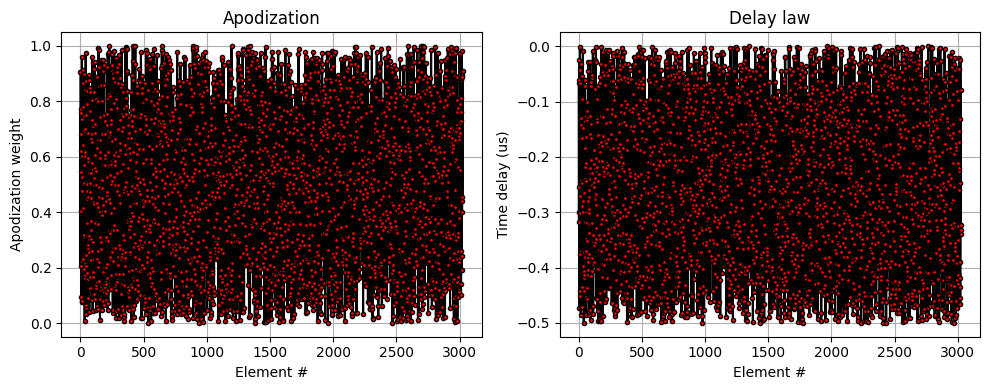

In [55]:
init_apod = np.random.rand(Zeus_Matrix.n_elem_x*Zeus_Matrix.n_elem_y)
init_delay = np.random.rand(Zeus_Matrix.n_elem_x*Zeus_Matrix.n_elem_y)

# Compute delays based on the speed of sound in soft tissue
init_delay = (init_delay.min()- init_delay)/2*1e-6  # time delays for focusing

# optionally plot
fig, ax = plt.subplots(1,2, figsize=(10, 4))
ax[0].plot(np.arange(Zeus_Matrix.n_elements), init_apod, 'k-', marker='o', markerfacecolor='r', ms = 3)
ax[0].set_xlabel("Element #")
ax[0].set_ylabel("Apodization weight")
ax[0].set_title("Apodization")
ax[0].grid(True)
ax[1].plot(np.arange(Zeus_Matrix.n_elements), init_delay*1e6, 'k-', marker='o', markerfacecolor='r', ms = 3)
ax[1].set_xlabel("Element #")
ax[1].set_ylabel("Time delay (us)")
ax[1].set_title("Delay law")
ax[1].grid(True)
plt.tight_layout()
plt.show()

In [57]:
Matrix_field = pyfield.PyField(Zeus_Matrix)
result_field, x, y, z = Matrix_field.compute_pressure_field(field_info_mm, inplace = False, normalize = False)


Successfully initialized PyField with 
 MatrixArrayTransducer(n_elem_x=55, n_elem_y=55, el_w_mm=0.29, kerf_x_mm=0.010000000000000009, kerf_y_mm=0.010000000000000009, no_sub_x=2, no_sub_y=2, fc_Hz=10000000.0)
Computing SIR for 5043 points and 12100 patches...
Total computation time: 10.6429 seconds.
Computing pressure field...
Performing FFT...
Frequency searched: 10000000.0 Hz. Found: 9965803.61504641 Hz


In [58]:

# Define optimizer on apod & delays
optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)


Initialized TorchField on cpu


In [59]:
field_torch, x, y, z = model(field_info_mm)  # forward pass
# To optimize, compute a loss: e.g. target focus at index 50

Grid created with shape: torch.Size([5043, 3]), x: 41, y: 41, z: 3
Computing SIR for 5043 points and 12100 transducer elements.
Accumulating events for 5043 points over 32 time samples.
SIR computed in 9.03 seconds
Computing pressure field from SIR with shape: torch.Size([32, 5043])
Pressure field computed succesfully


In [60]:
result_torch = field_torch.cpu().detach().numpy()

In [61]:
nx_target, ny_target, nz_target = result_field.shape
result = result_field[:,:,nz_target//2] / result_field.max()
result_to = result_torch[:,:,nz_target//2] / result_torch.max()


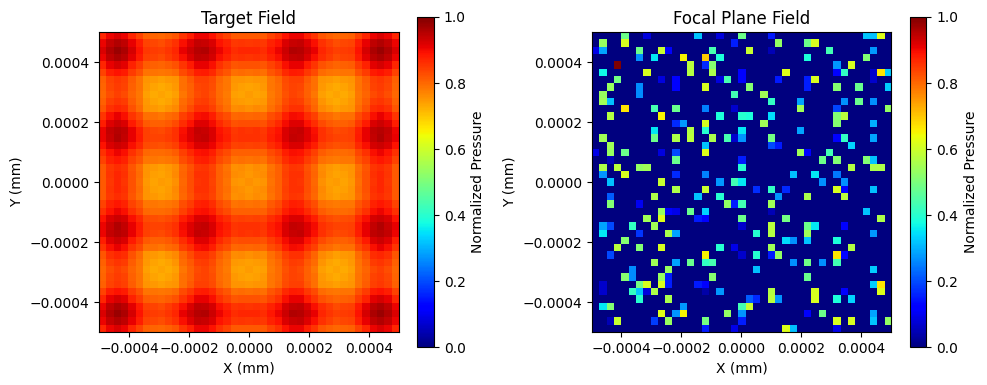

In [62]:
fig, ax = plt.subplots(1,2, figsize=(10, 4))
im1 = ax[0].imshow(result, extent=(x.min(), x.max(), y.min(), y.max()), vmin = 0, vmax = 1, cmap='jet')
ax[0].set_title("Target Field")
ax[0].set_xlabel("X (mm)")
ax[0].set_ylabel("Y (mm)")
fig.colorbar(im1, ax =ax[0], orientation='vertical', label='Normalized Pressure')

im2 = ax[1].imshow(result_to, extent=(x.min(), x.max(), y.min(), y.max()), vmin = 0, vmax = 1, cmap='jet')
ax[1].set_title("Focal Plane Field")
ax[1].set_xlabel("X (mm)")
ax[1].set_ylabel("Y (mm)")
fig.colorbar(im2, ax =ax[1], orientation='vertical', label='Normalized Pressure')

plt.tight_layout()
plt.show()

In [63]:

loss = nn.MSELoss()(amp, target)
loss.backward()
optimizer.step()
print('Loss:', loss.item())

NameError: name 'nn' is not defined